In [17]:
import numpy as np
import os
import pandas as pd
from lenstronomy.SimulationAPI.sim_api import SimAPI
import matplotlib.pyplot as plt

In [18]:


def make_lens_image(seed=None, redshift_range=(0.3, 5.0)):
    if seed is not None:
        np.random.seed(seed)

    theta_E = np.random.uniform(1.0, 2.0)
    source_offset = np.random.uniform(0.05, 0.2)
    source_redshift = np.random.uniform(*redshift_range)

    base_mag = 20.0
    source_mag = base_mag + 1.5 * source_redshift
    source_size = 0.3 / (1 + 0.5 * source_redshift)
    lens_mag = np.random.uniform(20.0, 21.5)

    kwargs_single_band = {
    'pixel_scale': 0.1,      # Euclid VIS pixel scale (was 0.263, SDSS)
    'exposure_time': 90,
    'magnitude_zero_point': 27.0,
    'read_noise': 7,
    'ccd_gain': 6.083,
    'sky_brightness': 23.5,
    'seeing': 0.16,           # Euclid VIS PSF FWHM (was 0.9, ground-based)
    'num_exposures': 1,
    'psf_type': 'GAUSSIAN'
}
    kwargs_model = {
        'lens_model_list': ['SIE'],
        'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    }

    sim = SimAPI(64, kwargs_single_band, kwargs_model)

    kwargs_lens_light_mag = [{'magnitude': lens_mag, 'R_sersic': 1.0,
                               'n_sersic': 4.0, 'e1': 0.1, 'e2': -0.1,
                               'center_x': 0.0, 'center_y': 0.0}]
    kwargs_source_mag = [{'magnitude': source_mag, 'R_sersic': source_size,
                           'n_sersic': 2.0, 'e1': 0.1, 'e2': -0.1,
                           'center_x': source_offset, 'center_y': source_offset}]
    kwargs_lens = [{'theta_E': theta_E, 'e1': 0.1, 'e2': -0.1,
                    'center_x': 0.0, 'center_y': 0.0}]

    kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(
        kwargs_lens_light_mag=kwargs_lens_light_mag,
        kwargs_source_mag=kwargs_source_mag)

    image_model = sim.image_model_class({'supersampling_factor': 1})
    image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source,
                               kwargs_lens_light=kwargs_lens_light)
    noise = sim.noise_for_model(model=image, background_noise=True, poisson_noise=True)
    return image + noise, source_redshift


def make_non_lens_image(seed=None):
    if seed is not None:
        np.random.seed(seed)

    kwargs_single_band = {
        'pixel_scale': 0.263, 'exposure_time': 90,
        'magnitude_zero_point': 27.0, 'read_noise': 7,
        'ccd_gain': 6.083, 'sky_brightness': 23.5,
        'seeing': 0.9, 'num_exposures': 1, 'psf_type': 'GAUSSIAN'
    }
    kwargs_model = {
        'lens_model_list': ['SIE'],
        'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    }

    sim = SimAPI(64, kwargs_single_band, kwargs_model)

    kwargs_lens_light_mag = [{'magnitude': 19.5, 'R_sersic': 1.0,
                               'n_sersic': 4.0, 'e1': 0.1, 'e2': -0.1,
                               'center_x': 0.0, 'center_y': 0.0}]
    kwargs_source_mag = [{'magnitude': 22.0, 'R_sersic': 0.3,
                           'n_sersic': 2.0, 'e1': 0.1, 'e2': -0.1,
                           'center_x': 5.0, 'center_y': 5.0}]
    kwargs_lens = [{'theta_E': 0.01, 'e1': 0.0, 'e2': 0.0,
                    'center_x': 0.0, 'center_y': 0.0}]

    kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(
        kwargs_lens_light_mag=kwargs_lens_light_mag,
        kwargs_source_mag=kwargs_source_mag)

    image_model = sim.image_model_class({'supersampling_factor': 1})
    image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source,
                               kwargs_lens_light=kwargs_lens_light)
    noise = sim.noise_for_model(model=image, background_noise=True, poisson_noise=True)
    return image + noise

In [19]:
def make_hard_non_lens_image(seed=None):
    """A galaxy with a nearby companion galaxy — but genuinely not lensed.
    This is much harder to distinguish from a real lens than a single isolated blob."""
    if seed is not None:
        np.random.seed(seed)

    kwargs_single_band = {
        'pixel_scale': 0.1,      # Euclid VIS pixel scale (was 0.263, SDSS)
        'exposure_time': 90,
        'magnitude_zero_point': 27.0,
        'read_noise': 7,
        'ccd_gain': 6.083,
        'sky_brightness': 23.5,
        'seeing': 0.16,           # Euclid VIS PSF FWHM (was 0.9, ground-based)
        'num_exposures': 1,
        'psf_type': 'GAUSSIAN'
    }
    kwargs_model = {
        'lens_model_list': ['SIE'],
        'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    }

    sim = SimAPI(64, kwargs_single_band, kwargs_model)

    # Main (foreground) galaxy - same as before
    lens_mag = np.random.uniform(20.0, 21.5)
    kwargs_lens_light_mag = [{'magnitude': lens_mag, 'R_sersic': 1.0,
                               'n_sersic': 4.0, 'e1': 0.1, 'e2': -0.1,
                               'center_x': 0.0, 'center_y': 0.0}]

    # "Companion" galaxy - nearby, but NOT behind the lens (no lensing distortion)
    # Randomize position enough to look like a real chance alignment, not an arc
    companion_offset_x = np.random.uniform(-1.0, 1.0)
    companion_offset_y = np.random.uniform(-1.0, 1.0)
    companion_mag = np.random.uniform(20.0, 22.0)
    companion_size = np.random.uniform(0.2, 0.5)

    kwargs_source_mag = [{'magnitude': companion_mag, 'R_sersic': companion_size,
                           'n_sersic': np.random.uniform(1.0, 4.0),  # varied morphology
                           'e1': np.random.uniform(-0.3, 0.3), 'e2': np.random.uniform(-0.3, 0.3),
                           'center_x': companion_offset_x, 'center_y': companion_offset_y}]

    # Negligible lensing mass - the companion's shape is intrinsic, not lensed
    kwargs_lens = [{'theta_E': 0.01, 'e1': 0.0, 'e2': 0.0,
                    'center_x': 0.0, 'center_y': 0.0}]

    kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(
        kwargs_lens_light_mag=kwargs_lens_light_mag,
        kwargs_source_mag=kwargs_source_mag)

    image_model = sim.image_model_class({'supersampling_factor': 1})
    image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source,
                               kwargs_lens_light=kwargs_lens_light)
    noise = sim.noise_for_model(model=image, background_noise=True, poisson_noise=True)
    return image + noise

In [20]:
os.makedirs("data_4/lens", exist_ok=True)
os.makedirs("data_4/nonlens", exist_ok=True)

records = []
n_per_class = 1000  # start small, scale up once this works

for i in range(n_per_class):
    img, z = make_lens_image(seed=i)
    path = f"data_4/lens/lens_{i}.npy"
    np.save(path, img)
    records.append({"file_path": path, "label": 1, "redshift": z})

for i in range(n_per_class):
    img = make_hard_non_lens_image(seed=1000 + i)
    path = f"data_4/nonlens/nonlens_{i}.npy"
    np.save(path, img)
    records.append({"file_path": path, "label": 0, "redshift": None})

df = pd.DataFrame(records)
df.to_csv("data_4/dataset.csv", index=False)
df.head()

,file_path,label,redshift
0,data_4/lens/lens_0.npy,1,3.132988
1,data_4/lens/lens_1.npy,1,0.300538
2,data_4/lens/lens_2.npy,1,2.883414
3,data_4/lens/lens_3.npy,1,1.667252
4,data_4/lens/lens_4.npy,1,4.871616


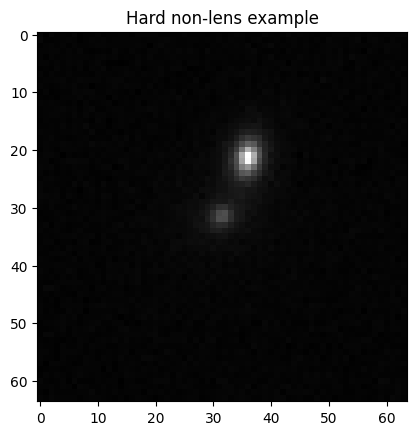

In [21]:
img = make_hard_non_lens_image(seed=1)
plt.imshow(img, cmap='gray')
plt.title("Hard non-lens example")
plt.show()

In [22]:
from PIL import Image

def normalize_and_save(img_array, save_path):
    """Convert a raw simulated array into a viewable PNG."""
    img = img_array.copy()
    # Clip extreme outliers, then normalize to 0-255
    img = np.clip(img, np.percentile(img, 0.5), np.percentile(img, 99.5))
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)  # scale 0-1
    img = (img * 255).astype(np.uint8)
    Image.fromarray(img).save(save_path)

os.makedirs("data_4/lens_png", exist_ok=True)
os.makedirs("data_4/nonlens_png", exist_ok=True)

records = []
n_per_class = 1000

for i in range(n_per_class):
    img, z = make_lens_image(seed=i)
    path = f"data_4/lens_png/lens_{i}.png"
    normalize_and_save(img, path)
    records.append({"file_path": path, "label": 1, "redshift": z})

for i in range(n_per_class):
    img = make_non_lens_image(seed=1000 + i)
    path = f"data_4/nonlens_png/nonlens_{i}.png"
    normalize_and_save(img, path)
    records.append({"file_path": path, "label": 0, "redshift": None})

df = pd.DataFrame(records)
df.to_csv("data_4/dataset.csv", index=False)
df.head()

,file_path,label,redshift
0,data_4/lens_png/lens_0.png,1,3.132988
1,data_4/lens_png/lens_1.png,1,0.300538
2,data_4/lens_png/lens_2.png,1,2.883414
3,data_4/lens_png/lens_3.png,1,1.667252
4,data_4/lens_png/lens_4.png,1,4.871616


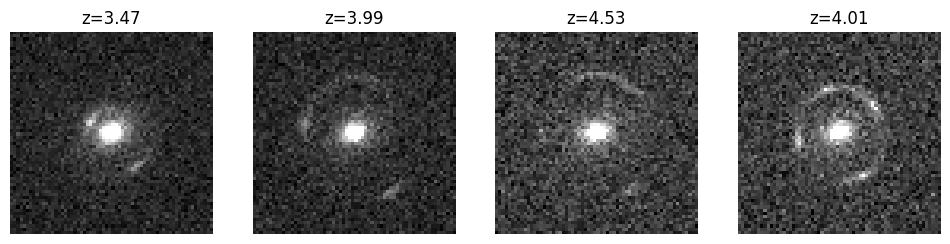

In [23]:
sample = df[df.label == 1].sample(4, random_state=1)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row.file_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"z={row.redshift:.2f}")
    ax.axis('off')
plt.show()

In [24]:
df = pd.read_csv("data_4/dataset.csv")

In [25]:
from sklearn.model_selection import train_test_split

df['file_loc'] = df['file_path']
df['id_str'] = df.index.astype(str)  # simple unique ID per row

# Redo the train/val/test split with the updated columns
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df.label)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df.label)

test_df.to_csv("data_4/test_set_with_redshift.csv", index=False)  # re-save with correct columns

In [26]:
import zoobot
print(zoobot.__file__)

/Users/shubhisharvil/external_repos/zoobot/zoobot/__init__.py


In [27]:
from galaxy_datasets.pytorch.galaxy_datamodule import CatalogDataModule

datamodule = CatalogDataModule(
    label_cols=['label'],
    train_catalog=train_df,
    val_catalog=val_df,
    test_catalog=test_df,
    predict_catalog=test_df,   # same data, but registered for the predict stage
    batch_size=32,
    num_workers=7
)

In [28]:
from zoobot.pytorch.training import finetune

model = finetune.FinetuneableZoobotClassifier(
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    num_classes=2,
    label_col='label',
    training_mode='head_only',   # start conservative — just train the classifier head
    learning_rate=1e-4,
    greyscale=True,               # your simulated images are single-band
)

In [29]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

early_stop_callback = EarlyStopping(

    monitor="finetuning/val_loss", 
    mode="min",          # Tells Lightning that "lower value = better performance"
    patience=5           # Stops training if it fails to decrease for 5 straight epochs
)

trainer = L.Trainer(
    callbacks=[early_stop_callback],
    max_epochs=30,          # keep this small for a first test run
    accelerator='auto',     # will use GPU/MPS if available, otherwise CPU
    devices=1,
    enable_progress_bar=True,
    logger=False,           # skip fancy logging setup for now, keep it simple
   
)



trainer.fit(model, datamodule=datamodule)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/shubhisharvil/lens_env/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/shubhisharvil/ACM_2026/Implementation_5/checkpoints exists and is not empty.

  | Name              | Type           | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | encoder           | ConvNeXt       | 14.9 M | train | 0    
1 | train_loss_metric | MeanMetric     | 0      | train | 0    
2 | va

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/shubhisharvil/lens_env/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/shubhisharvil/lens_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skippingGZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [30]:
predictions = trainer.predict(model, datamodule=datamodule)

Predicting: |          | 0/? [00:00<?, ?it/s]

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skippingGZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


In [31]:
print(type(predictions), len(predictions))
print(predictions[0])

<class 'list'> 13
tensor([[9.9685e-01, 3.1475e-03],
        [9.9361e-01, 6.3924e-03],
        [3.6334e-03, 9.9637e-01],
        [9.9824e-01, 1.7608e-03],
        [9.9729e-01, 2.7096e-03],
        [3.7553e-02, 9.6245e-01],
        [7.2224e-02, 9.2778e-01],
        [9.9830e-01, 1.6988e-03],
        [9.9794e-01, 2.0625e-03],
        [5.9549e-02, 9.4045e-01],
        [9.9472e-01, 5.2825e-03],
        [5.1500e-03, 9.9485e-01],
        [9.9787e-01, 2.1263e-03],
        [3.5242e-03, 9.9648e-01],
        [9.9628e-01, 3.7236e-03],
        [9.9633e-01, 3.6725e-03],
        [9.9746e-01, 2.5411e-03],
        [9.9757e-01, 2.4322e-03],
        [1.5889e-03, 9.9841e-01],
        [1.2391e-01, 8.7609e-01],
        [8.7362e-04, 9.9913e-01],
        [9.9704e-01, 2.9586e-03],
        [3.0796e-03, 9.9692e-01],
        [7.0574e-03, 9.9294e-01],
        [1.0827e-03, 9.9892e-01],
        [9.9812e-01, 1.8846e-03],
        [9.2739e-03, 9.9073e-01],
        [9.9783e-01, 2.1728e-03],
        [9.9489e-01, 5.1124e-0

In [32]:
import torch

# Combine all batches into one tensor
all_preds = torch.cat(predictions, dim=0)  # shape: [total_test_images, 2]
print(all_preds.shape, len(test_df))

torch.Size([400, 2]) 400


In [33]:
predictions = trainer.predict(model, datamodule=datamodule)
all_preds = torch.cat(predictions, dim=0)
print(all_preds.shape, len(test_df))  # sanity check shapes match again

predicted_class = all_preds.argmax(dim=1).numpy()
lens_confidence = all_preds[:, 1].numpy()

test_df = test_df.reset_index(drop=True)
test_df['predicted_label'] = predicted_class
test_df['lens_confidence'] = lens_confidence
test_df['correct'] = (test_df['predicted_label'] == test_df['label'])

Predicting: |          | 0/? [00:00<?, ?it/s]

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
torch.Size([400, 2]) 400


In [34]:
lens_test = test_df[test_df['label'] == 1].copy()
bins = [0.3, 0.9, 1.5, 2.0, 3.0, 4.0, 5.0]
labels = ['low (0.3-0.9)', 'mid (0.9-1.5)', 'high (1.5-2.0)', 'v high (2.0 - 3.0)', '(3.0,4.0)', '(4.0, 5.0)']
lens_test['z_bucket'] = pd.cut(lens_test['redshift'], bins=bins, labels=labels, include_lowest=True)

bucket_summary = lens_test.groupby('z_bucket', observed=True).agg(
    n=('correct', 'size'),
    accuracy=('correct', 'mean'),
    avg_confidence=('lens_confidence', 'mean')
)
print(bucket_summary)

                     n  accuracy  avg_confidence
z_bucket                                        
low (0.3-0.9)       26  1.000000        0.990808
mid (0.9-1.5)       19  1.000000        0.994559
high (1.5-2.0)      25  1.000000        0.992081
v high (2.0 - 3.0)  36  1.000000        0.995532
(3.0,4.0)           38  1.000000        0.993534
(4.0, 5.0)          56  0.892857        0.855237


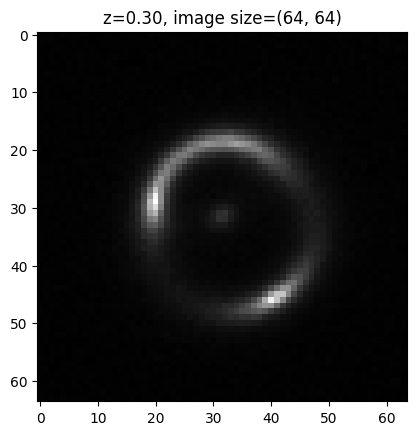

In [35]:
img, z = make_lens_image(seed=1)
plt.imshow(img, cmap='gray')
plt.title(f"z={z:.2f}, image size={img.shape}")
plt.show()

In [36]:
def edge_fraction(img, border=3):
    """What fraction of total image brightness is in the outer `border` pixels?"""
    total = img.sum()
    mask = np.ones_like(img, dtype=bool)
    mask[border:-border, border:-border] = False  # True only on the border ring
    edge_flux = img[mask].sum()
    return edge_flux / total if total > 0 else 0

edge_fractions = []
for i in range(200):
    img, z = make_lens_image(seed=i)
    edge_fractions.append(edge_fraction(img))

edge_fractions = np.array(edge_fractions)
print(f"Mean edge fraction: {edge_fractions.mean():.4f}")
print(f"Max edge fraction: {edge_fractions.max():.4f}")
print(f"How many images have >5% of light near the edge: {(edge_fractions > 0.05).sum()} / 200")

Mean edge fraction: 0.0138
Max edge fraction: 0.0508
How many images have >5% of light near the edge: 1 / 200
